# Week 2 — Data Cleaning & Preprocessing

Task
Using the same dataset:

* Handle missing values
* Remove duplicates
* Encode categorical variables
* Normalize numerical features

### Step 1: Handle Missing Values:

The dataset contained missing values in the INR, AED, and CNY columns. Missing values were replaced with the median value of their respective columns because the median is less affected by extreme values and preserves the overall distribution of the data.

### Step 2: Remove Duplicates:
Duplicate rows were identified using the duplicated() function and removed using drop_duplicates(). This ensures that no repeated records affect the analysis.
* Code Used: df.drop_duplicates(inplace=True)

### Step 3: Encode Categorical Variables
The dataset does not contain any categorical columns. The Date column consists of year values (1978–2021), which are already numeric. For better readability, the column was renamed from Date to Year.
* Code Used:df.rename(columns={"Date": "Year"}, inplace=True)

### Step 4: Normalize Numerical Features
The dataset contains values with different scales. For example, USD values are in hundreds while INR values are in thousands. To bring all features to a common scale, Min-Max Normalization was applied, transforming values to the range 0 to 1. 1
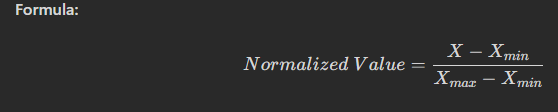

In [1]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Load dataset
df = pd.read_csv("annual_gold_rate.csv")

print("="*50)
print("ORIGINAL DATASET")
print("="*50)
print(df.head())

ORIGINAL DATASET
   Date     USD        EUR        GBP         INR         AED  CNY
0  1978  193.44  124.73580  100.65449         NaN         NaN  NaN
1  1979  304.68  185.06142  143.09014  2481.90512  1163.93597  NaN
2  1980  614.50  378.19461  263.80259  4831.74943  2278.36795  NaN
3  1981  459.26  360.90588  227.01948  3966.64790  1691.03194  NaN
4  1982  375.30  345.59742  215.53232  3553.62680  1378.72895  NaN


### Handling Missing Values

In [2]:
# ----------------------------------
# TASK 1: HANDLE MISSING VALUES
# ----------------------------------

print("\nTASK 1: HANDLE MISSING VALUES")

print("\nMissing Values Before:")
print(df.isnull().sum())

df.fillna(df.median(numeric_only=True), inplace=True)

print("\nMissing Values After:")
print(df.isnull().sum())


TASK 1: HANDLE MISSING VALUES

Missing Values Before:
Date    0
USD     0
EUR     0
GBP     0
INR     1
AED     1
CNY     7
dtype: int64

Missing Values After:
Date    0
USD     0
EUR     0
GBP     0
INR     0
AED     0
CNY     0
dtype: int64


### Removing Duplicate Values

In [3]:
# ----------------------------------
# TASK 2: REMOVE DUPLICATES
# ----------------------------------

print("\nTASK 2: REMOVE DUPLICATES")

print("Duplicate Rows Before:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("Duplicate Rows After:", df.duplicated().sum())


TASK 2: REMOVE DUPLICATES
Duplicate Rows Before: 0
Duplicate Rows After: 0


### Encode Categorical Variables

In [4]:
# ----------------------------------
# TASK 3: ENCODE CATEGORICAL VARIABLES
# ----------------------------------

print("\nTASK 3: ENCODE CATEGORICAL VARIABLES")

df.rename(columns={"Date": "Year"}, inplace=True)

print(df[["Year"]].head())


TASK 3: ENCODE CATEGORICAL VARIABLES
   Year
0  1978
1  1979
2  1980
3  1981
4  1982


### Normalize Numerical features

In [5]:
# ----------------------------------
# TASK 4: NORMALIZE NUMERICAL FEATURES
# ----------------------------------

print("\nTASK 4: NORMALIZE NUMERICAL FEATURES")

scaler = MinMaxScaler()

df = pd.DataFrame(
    scaler.fit_transform(df),
    columns=df.columns
)

print(df.head())


TASK 4: NORMALIZE NUMERICAL FEATURES
       Year       USD       EUR       GBP       INR       AED       CNY
0  0.000000  0.000000  0.000000  0.000000  0.078986  0.100151  0.210982
1  0.023256  0.069301  0.042354  0.033196  0.000000  0.030018  0.210982
2  0.046512  0.262315  0.177952  0.127626  0.018008  0.228632  0.210982
3  0.069767  0.165602  0.165814  0.098852  0.011379  0.123957  0.210982
4  0.093023  0.113296  0.155066  0.089866  0.008213  0.068298  0.210982


### Saving the cleaned Dataset

In [6]:
# ----------------------------------
# SAVE CLEAN DATASET
# ----------------------------------

df.to_csv("annual_gold_rate_cleaned.csv", index=False)

print("\nClean dataset saved as annual_gold_rate_cleaned.csv")


Clean dataset saved as annual_gold_rate_cleaned.csv
